# RheolNet Day 1: 2D Poiseuille PINN Baseline

This notebook builds the Person 1 baseline for RheolNet. It solves a 2D steady Poiseuille flow problem with a physics-informed neural network, validates against the analytical solution, and saves a figure called `validation_day1.png`.

The goal is to confirm that PyTorch autograd, second derivatives, Tanh activations, and the PINN loss pipeline are all working before extending the code to Carreau-Yasuda rheology.

In [21]:
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

torch.set_default_dtype(torch.float32)

def select_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        probe = torch.zeros(1, device='cuda')
        probe = probe + 1
        _ = probe.cpu()
        return torch.device('cuda')
    except Exception as exc:
        print('CUDA is visible but this torch build cannot run kernels on it, so falling back to CPU.')
        print(type(exc).__name__, exc)
        return torch.device('cpu')

device = select_device()
print('Using device:', device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

CUDA is visible but this torch build cannot run kernels on it, so falling back to CPU.
AcceleratorError CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Using device: cpu


## Problem setup

This baseline is trained on synthetic data only: interior collocation points sampled from the PDE domain, boundary points enforcing no-slip and pressure conditions, and the analytic Poiseuille solution used as supervision at the boundaries and for validation.

We solve a manufactured 2D steady Poiseuille solution in the unit square $x \in [0,1]$, $y \in [0,1]$. The exact solution is:

$$
u(x,y) = 4y(1-y), \quad v(x,y) = 0, \quad p(x,y) = -8x.
$$

With viscosity $\nu = 1$, this satisfies the steady incompressible Navier-Stokes equations in the low-Reynolds-number limit. This is a clean baseline for testing the PINN pipeline before moving to Carreau-Yasuda rheology.

In [22]:
@dataclass
class Config:
    n_collocation: int = 1024
    n_boundary: int = 256
    n_train_steps: int = 2000
    learning_rate: float = 1e-3
    hidden_layers: int = 4
    hidden_width: int = 64
    viscosity: float = 1.0

cfg = Config()

def exact_solution(xy):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    u = 4.0 * y * (1.0 - y)
    v = torch.zeros_like(u)
    p = -8.0 * x
    return u, v, p

def sample_interior(n):
    xy = torch.rand(n, 2, device=device)
    xy.requires_grad_(True)
    return xy

def sample_boundary(n):
    n_side = n // 4
    y = torch.rand(n_side, 1, device=device)
    x = torch.rand(n_side, 1, device=device)

    bottom = torch.cat([x, torch.zeros_like(x)], dim=1)
    top = torch.cat([x, torch.ones_like(x)], dim=1)
    left = torch.cat([torch.zeros_like(y), y], dim=1)
    right = torch.cat([torch.ones_like(y), y], dim=1)

    boundary = torch.cat([bottom, top, left, right], dim=0)
    boundary.requires_grad_(True)
    return boundary

In [23]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=3, hidden_layers=4, hidden_width=64):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_width), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.extend([nn.Linear(hidden_width, hidden_width), nn.Tanh()])
        layers.append(nn.Linear(hidden_width, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = PINN(hidden_layers=cfg.hidden_layers, hidden_width=cfg.hidden_width).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
mse = nn.MSELoss()

def gradients(outputs, inputs):
    return torch.autograd.grad(
        outputs=outputs,
        inputs=inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

def pde_residuals(xy):
    pred = model(xy)
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]

    grad_u = gradients(u, xy)
    grad_v = gradients(v, xy)
    grad_p = gradients(p, xy)

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]
    v_x = grad_v[:, 0:1]
    v_y = grad_v[:, 1:2]
    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    u_xx = gradients(u_x, xy)[:, 0:1]
    u_yy = gradients(u_y, xy)[:, 1:2]
    v_xx = gradients(v_x, xy)[:, 0:1]
    v_yy = gradients(v_y, xy)[:, 1:2]

    continuity = u_x + v_y
    momentum_x = u * u_x + v * u_y + p_x - cfg.viscosity * (u_xx + u_yy)
    momentum_y = u * v_x + v * v_y + p_y - cfg.viscosity * (v_xx + v_yy)
    return continuity, momentum_x, momentum_y

In [ ]:
CHECKPOINT_DIR = '/kaggle/working/day1_checkpoints'
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'day1_checkpoint.pt')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def get_rng_state():
    state = {
        'python_random': random.getstate(),
        'numpy_random': np.random.get_state(),
        'torch_random': torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state['torch_cuda_random'] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state):
    random.setstate(state['python_random'])
    np.random.set_state(state['numpy_random'])
    torch.set_rng_state(state['torch_random'])
    if torch.cuda.is_available() and 'torch_cuda_random' in state:
        torch.cuda.set_rng_state_all(state['torch_cuda_random'])


def save_checkpoint(path, step, model, optimizer, history):
    payload = {
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'rng_state': get_rng_state(),
        'cfg': cfg.__dict__,
    }
    torch.save(payload, path)
    print(f'Saved checkpoint to {path} at step {step}')


def load_checkpoint(path, model, optimizer):
    if not os.path.exists(path):
        return 0, {'total': [], 'physics': [], 'boundary': []}

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'rng_state' in checkpoint:
        set_rng_state(checkpoint['rng_state'])

    loaded_history = checkpoint.get('history', {'total': [], 'physics': [], 'boundary': []})
    loaded_step = int(checkpoint.get('step', 0))
    print(f'Loaded checkpoint from {path} at step {loaded_step}')
    return loaded_step, loaded_history


start_step, history = load_checkpoint(CHECKPOINT_PATH, model, optimizer)
print('Resume step:', start_step)

In [ ]:
if 'model' not in globals() or 'history' not in globals():
    raise RuntimeError('Run the model definition, checkpoint, and setup cells above before training.')

history = history if 'history' in globals() else {
    'total': [],
    'physics': [],
    'boundary': [],
}

save_every = 250

total_start = start_step + 1 if 'start_step' in globals() else 1

for step in range(total_start, cfg.n_train_steps + 1):
    optimizer.zero_grad()

    xy_f = sample_interior(cfg.n_collocation)
    xy_b = sample_boundary(cfg.n_boundary)

    continuity, momentum_x, momentum_y = pde_residuals(xy_f)
    physics_loss = mse(continuity, torch.zeros_like(continuity)) + mse(momentum_x, torch.zeros_like(momentum_x)) + mse(momentum_y, torch.zeros_like(momentum_y))

    pred_b = model(xy_b)
    u_b, v_b, p_b = pred_b[:, 0:1], pred_b[:, 1:2], pred_b[:, 2:3]
    u_true_b, v_true_b, p_true_b = exact_solution(xy_b)
    boundary_loss = mse(u_b, u_true_b) + mse(v_b, v_true_b) + mse(p_b, p_true_b)

    total_loss = physics_loss + 10.0 * boundary_loss
    total_loss.backward()
    optimizer.step()

    history['total'].append(total_loss.item())
    history['physics'].append(physics_loss.item())
    history['boundary'].append(boundary_loss.item())

    if step % 500 == 0 or step == 1 or step == cfg.n_train_steps:
        print(f'Step {step:5d} | total={total_loss.item():.4e} | physics={physics_loss.item():.4e} | boundary={boundary_loss.item():.4e}')

    if step % save_every == 0 or step == cfg.n_train_steps:
        save_checkpoint(CHECKPOINT_PATH, step, model, optimizer, history)

Step     1 | total=2.7684e+02 | physics=3.4911e-03 | boundary=2.7683e+01
Step   500 | total=9.8659e-02 | physics=5.0848e-02 | boundary=4.7812e-03
Step  1000 | total=1.9293e-02 | physics=1.0947e-02 | boundary=8.3461e-04
Step  1500 | total=6.5701e-03 | physics=3.4646e-03 | boundary=3.1055e-04
Step  2000 | total=3.6326e-03 | physics=1.4571e-03 | boundary=2.1755e-04


u relative L2 error: 0.003823
p relative L2 error: 0.003889


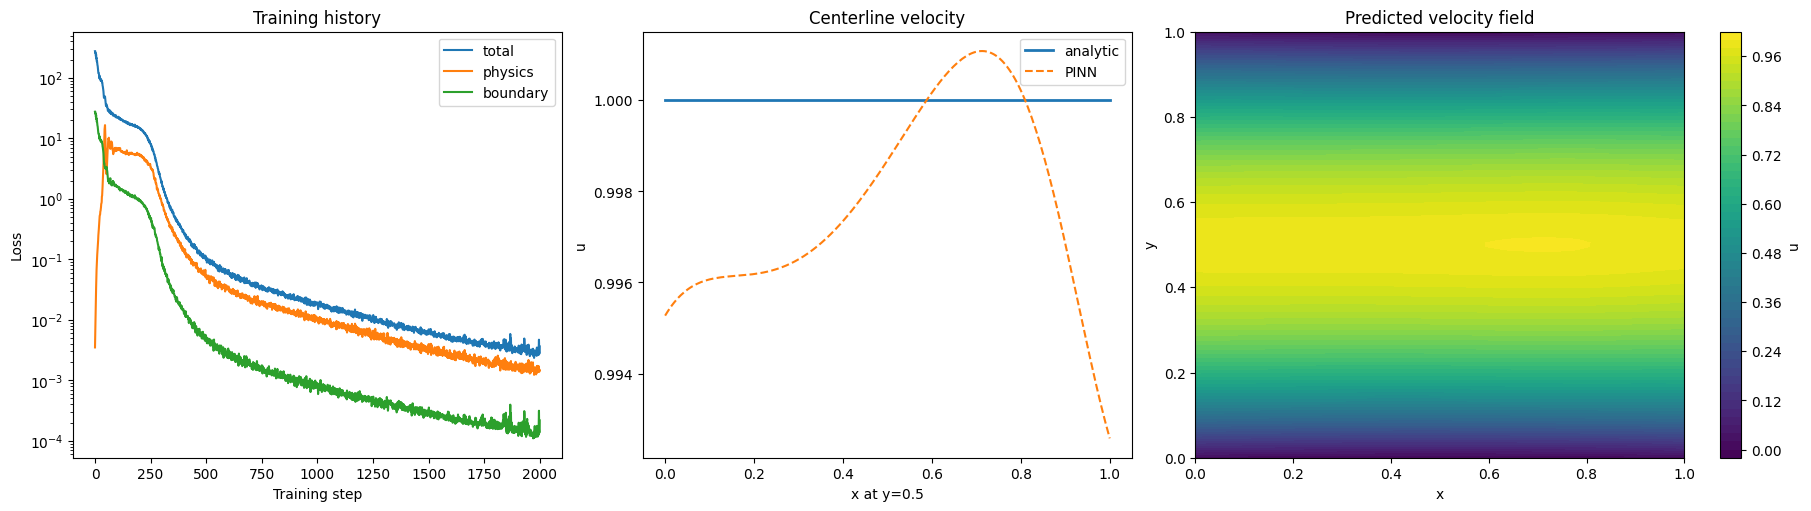

In [25]:
if 'model' not in globals() or 'history' not in globals():
    raise RuntimeError('Run the model definition and training cells above before the validation cell.')

model.eval()

nx, ny = 120, 120
x = torch.linspace(0.0, 1.0, nx, device=device)
y = torch.linspace(0.0, 1.0, ny, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')
xy_grid = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

with torch.no_grad():
    pred_grid = model(xy_grid)
    u_pred = pred_grid[:, 0].reshape(nx, ny).cpu().numpy()
    v_pred = pred_grid[:, 1].reshape(nx, ny).cpu().numpy()
    p_pred = pred_grid[:, 2].reshape(nx, ny).cpu().numpy()

u_true, v_true, p_true = exact_solution(xy_grid)
u_true = u_true.detach().reshape(nx, ny).cpu().numpy()
v_true = v_true.detach().reshape(nx, ny).cpu().numpy()
p_true = p_true.detach().reshape(nx, ny).cpu().numpy()

u_error_l2 = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)
p_error_l2 = np.linalg.norm(p_pred - p_true) / np.linalg.norm(p_true)
print(f'u relative L2 error: {u_error_l2:.6f}')
print(f'p relative L2 error: {p_error_l2:.6f}')

centerline = torch.stack([torch.linspace(0.0, 1.0, 200, device=device), 0.5 * torch.ones(200, device=device)], dim=1)
with torch.no_grad():
    center_pred = model(centerline)[:, 0].cpu().numpy()
    center_true = exact_solution(centerline)[0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

loss_ax = axes[0]
loss_ax.semilogy(history['total'], label='total')
loss_ax.semilogy(history['physics'], label='physics')
loss_ax.semilogy(history['boundary'], label='boundary')
loss_ax.set_xlabel('Training step')
loss_ax.set_ylabel('Loss')
loss_ax.set_title('Training history')
loss_ax.legend()

profile_ax = axes[1]
profile_ax.plot(np.linspace(0.0, 1.0, 200), center_true, label='analytic', linewidth=2)
profile_ax.plot(np.linspace(0.0, 1.0, 200), center_pred, '--', label='PINN')
profile_ax.set_xlabel('x at y=0.5')
profile_ax.set_ylabel('u')
profile_ax.set_title('Centerline velocity')
profile_ax.legend()

field_ax = axes[2]
contour = field_ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), u_pred, levels=50, cmap='viridis')
fig.colorbar(contour, ax=field_ax, label='u')
field_ax.set_xlabel('x')
field_ax.set_ylabel('y')
field_ax.set_title('Predicted velocity field')

plt.savefig('validation_day1.png', dpi=200, bbox_inches='tight')
plt.show()

## Day 1 checklist

If this notebook runs successfully and the analytic curve matches the PINN prediction closely, Person 1 can extend the same residual pipeline to Carreau-Yasuda viscosity by replacing the constant viscosity term with the shear-dependent viscosity function.

Next integration step: connect collocation points from Person 2's geometry loader into this training loop.